<a href="https://colab.research.google.com/github/AndrewZavala/GestaltLab/blob/main/likelihood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -q https://raw.githubusercontent.com/tsunrise/colab-github/main/colab_github.py
import colab_github
colab_github.github_auth(persistent_key=False)

Please go to https://github.com/settings/ssh/new to upload the following key: 
ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAIKwWC8EhOtrmSIh9Ly0XHKJX3uGAn48ZoJ5zMRpZ1TBt root@d79a7f72e263

Please use SSH method to clone repo.


In [ ]:
repo = "mscf/PRD-Lab-Experiments" #@param {"type": "string"}

addr = f"git@github.com:{repo}.git"
!git clone $addr

Cloning into 'PRD-Lab-Experiments'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 22 (delta 4), reused 11 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 7.52 MiB | 28.85 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [ ]:
%cd PRD-Lab-Experiments

/content/PRD-Lab-Experiments


In [ ]:
from matplotlib import pyplot as plt
from matplotlib import patches
import seaborn as sns
from participant import load_data
from functools import partial
from scipy import signal
import scipy as sp
import numpy as np
import pandas as pd
sns.set_theme()
rng = np.random.default_rng()

plt.rcParams['figure.figsize'] = (16, 12)

In [ ]:
participants = load_data("raw_data.csv", fs=100, highpass=4, lowpass=18)
participants_42 = load_data("raw_data.csv", fs=100, highpass=4, lowpass=18, seed=42)

In [ ]:
len(participants)

26

(51, 1000)


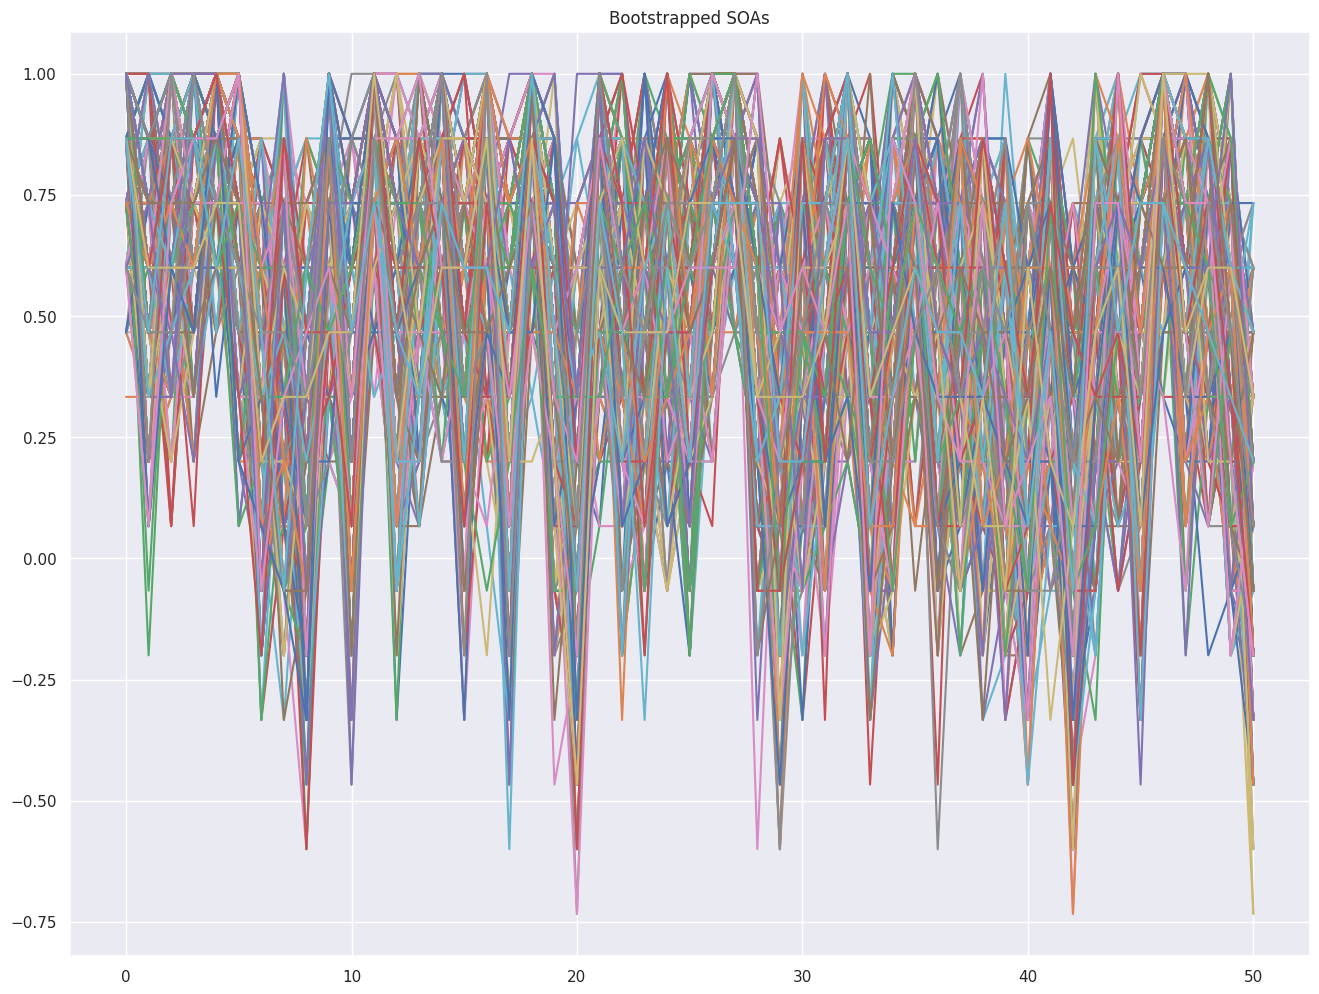

In [ ]:
print(participants[0]._bootstrapped_soas.shape)
plt.plot(participants[0]._bootstrapped_soas)
plt.title("Bootstrapped SOAs")
plt.show()

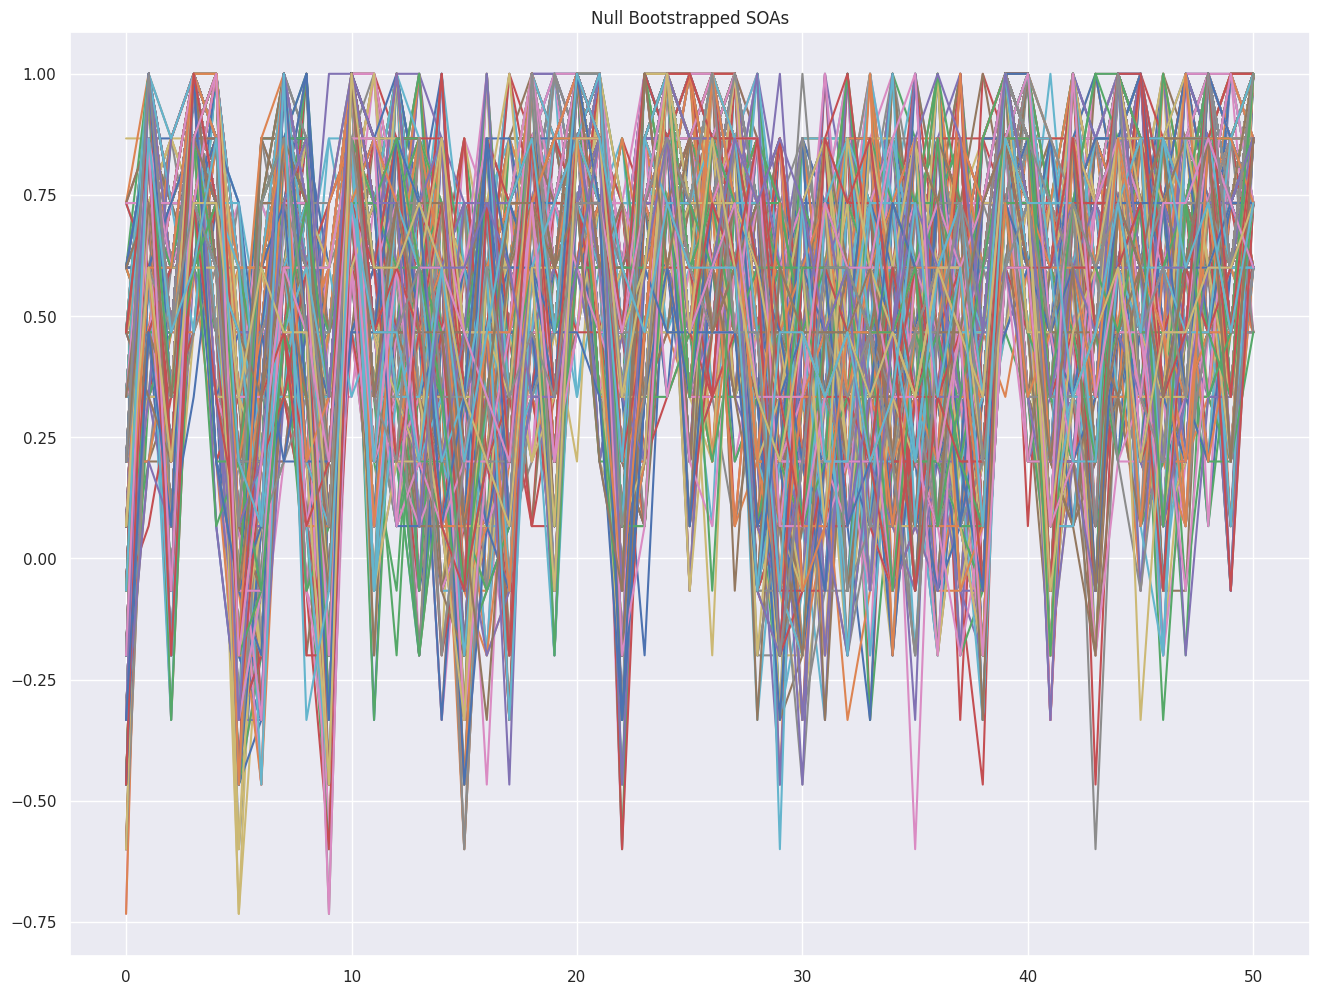

In [ ]:
plt.plot(participants[0].new_null_bootstrapped_soas)
plt.title("Null Bootstrapped SOAs")
plt.show()

In [ ]:
participants[0].soas.values()

dict_values([array([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
        1.,  1.]), array([ 1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1.,
        1.,  1.]), array([ 1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.]), array([-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,
        1.,  1.]), array([ 1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.]), array([ 1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
        1.,  1.]), array([ 1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1.,
        1., -1.]), array([ 1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1.,
        1.,  1.]), array([-1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1.,  1.,
       -1.,  1.]), array([-1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.]), array([-1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,
     

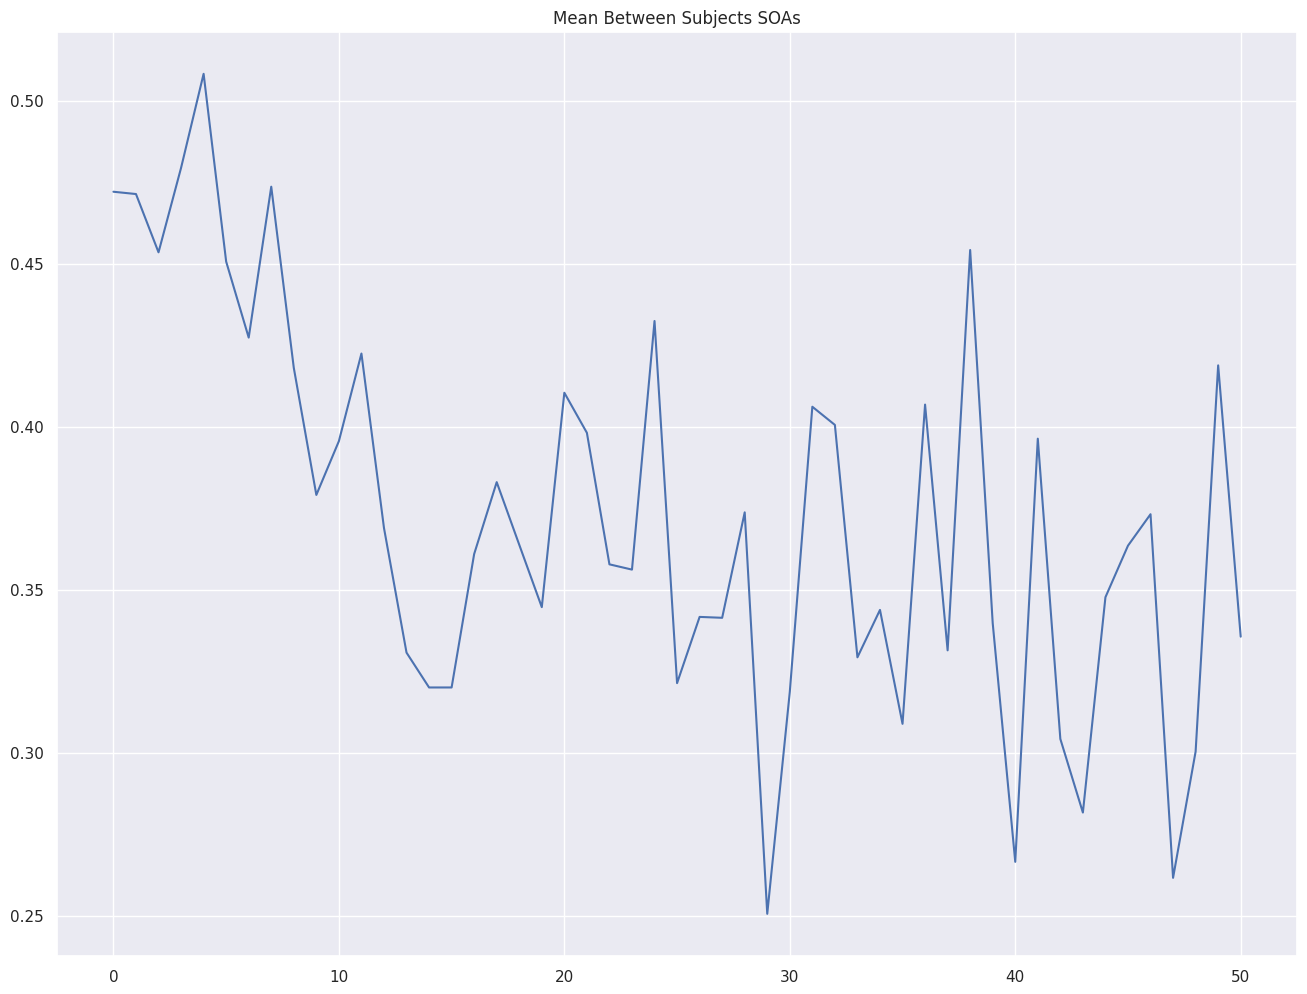

In [ ]:
soas = []
for p in participants:
  soas.append([np.mean(s) for k,s in p.soas.items()])

soas = np.mean(np.array(soas), axis=0)
plt.plot(soas)
plt.title("Mean Between Subjects SOAs")
plt.show()

In [ ]:
def plot_ci(bootstrap, label=None):
  mean_vals = []
  lower     = []
  upper     = []
  for i in range(len(bootstrap.confidence_interval.low)):
    lower.append(bootstrap.confidence_interval.low[i])
    upper.append(bootstrap.confidence_interval.high[i])
    mean_vals.append(bootstrap.bootstrap_distribution[i, :].mean())
  plt.plot(np.linspace(0, 50, len(bootstrap.confidence_interval.low)), mean_vals, label=label)
  plt.fill_between(np.linspace(0, 50, len(bootstrap.confidence_interval.low)), lower, upper, alpha=0.3, label=f"{label} 95% CI")

In [ ]:
rng =  np.random.default_rng(1337)
model_means = []
null_means = []
for p in participants:

  model_means.append(p.noisy_model_ffts.mean(axis=0))
  null_means.append(p.new_null_ffts.mean(axis=0))

In [ ]:
model_means_42 = []
null_means_42 = []
for p in participants_42:

  model_means_42.append(p.noisy_model_ffts.mean(axis=0))
  null_means_42.append(p.new_null_ffts.mean(axis=0))

[array([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
        1.,  1.]), array([ 1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1.,
        1.,  1.]), array([ 1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.]), array([-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,
        1.,  1.]), array([ 1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.]), array([ 1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
        1.,  1.]), array([ 1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1.,
        1., -1.]), array([ 1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1.,
        1.,  1.]), array([-1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1.,  1.,
       -1.,  1.]), array([-1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.]), array([-1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,
       -1.,  1.])

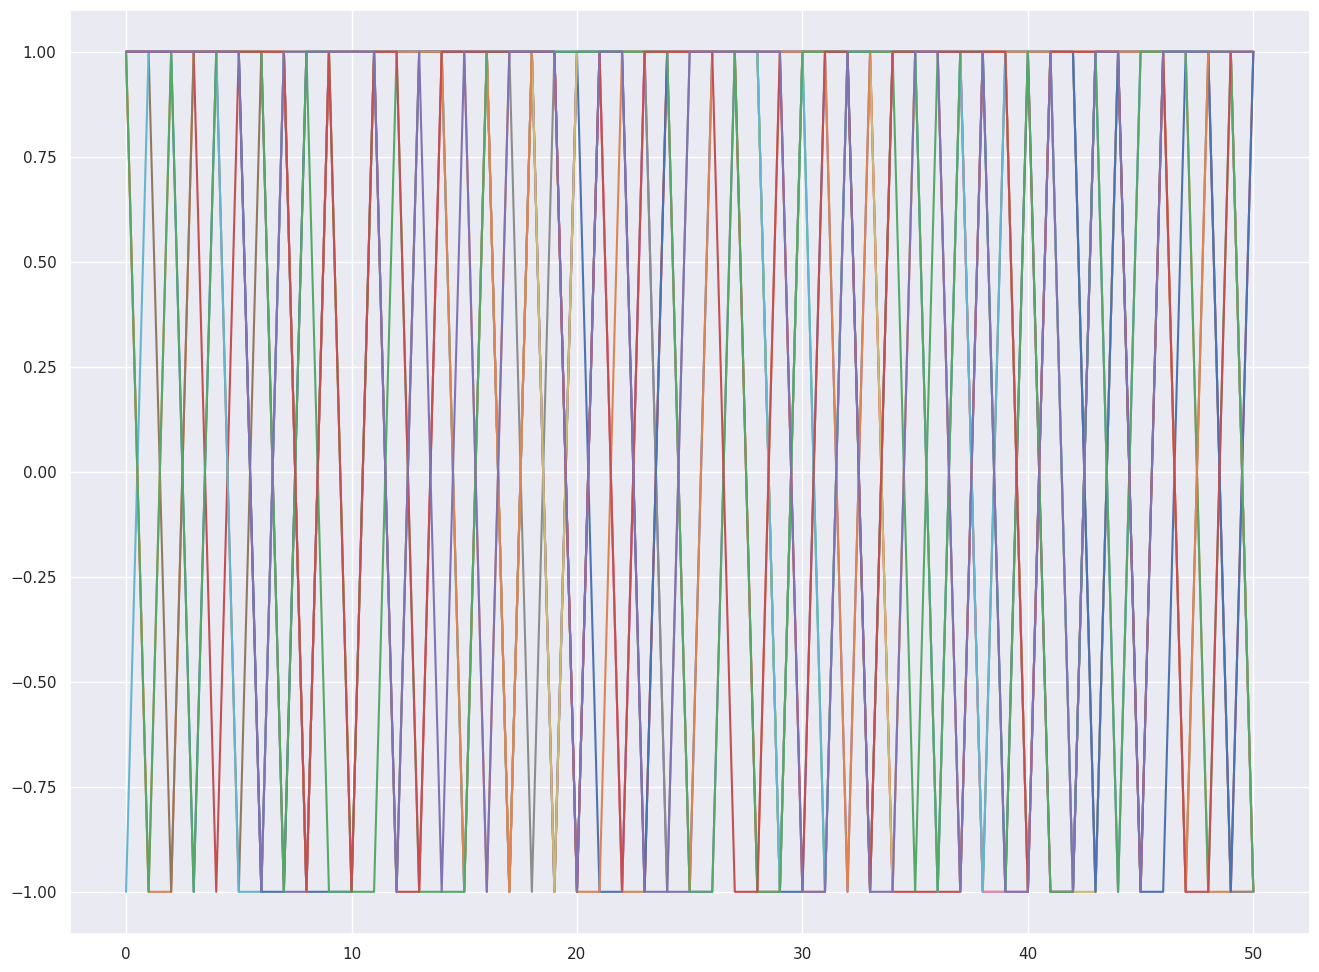

[array([ 1.,  1., -1.,  1., -1., -1., -1.,  1., -1., -1.,  1.,  1.,  1.,
       -1., -1.]), array([ 1., -1., -1.,  1., -1.,  1., -1.,  1., -1., -1., -1.,  1., -1.,
        1., -1.]), array([-1.,  1.,  1.,  1., -1.,  1., -1., -1., -1.,  1., -1.,  1., -1.,
       -1.,  1.]), array([ 1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
       -1.]), array([ 1.,  1.,  1.,  1., -1.,  1., -1.,  1.,  1., -1.,  1.,  1.,  1.,
        1., -1.]), array([-1.,  1.,  1.,  1.,  1., -1., -1.,  1., -1.,  1., -1.,  1.,  1.,
        1., -1.]), array([ 1.,  1.,  1., -1., -1., -1.,  1., -1.,  1., -1.,  1.,  1., -1.,
       -1.]), array([ 1., -1., -1.,  1., -1., -1., -1.,  1.,  1.,  1., -1.,  1.,  1.,
        1., -1.]), array([ 1.,  1., -1.,  1.,  1., -1., -1.,  1.,  1., -1., -1.,  1., -1.,
        1., -1.]), array([-1.,  1., -1.,  1., -1., -1., -1.,  1.,  1., -1., -1.,  1.,  1.,
       -1., -1.]), array([ 1., -1.,  1., -1.,  1.,  1., -1.,  1.,  1., -1., -1.,  1.,  1.,
       -1., -1.]), array([-

ValueError: Input could not be cast to an at-least-1D NumPy array

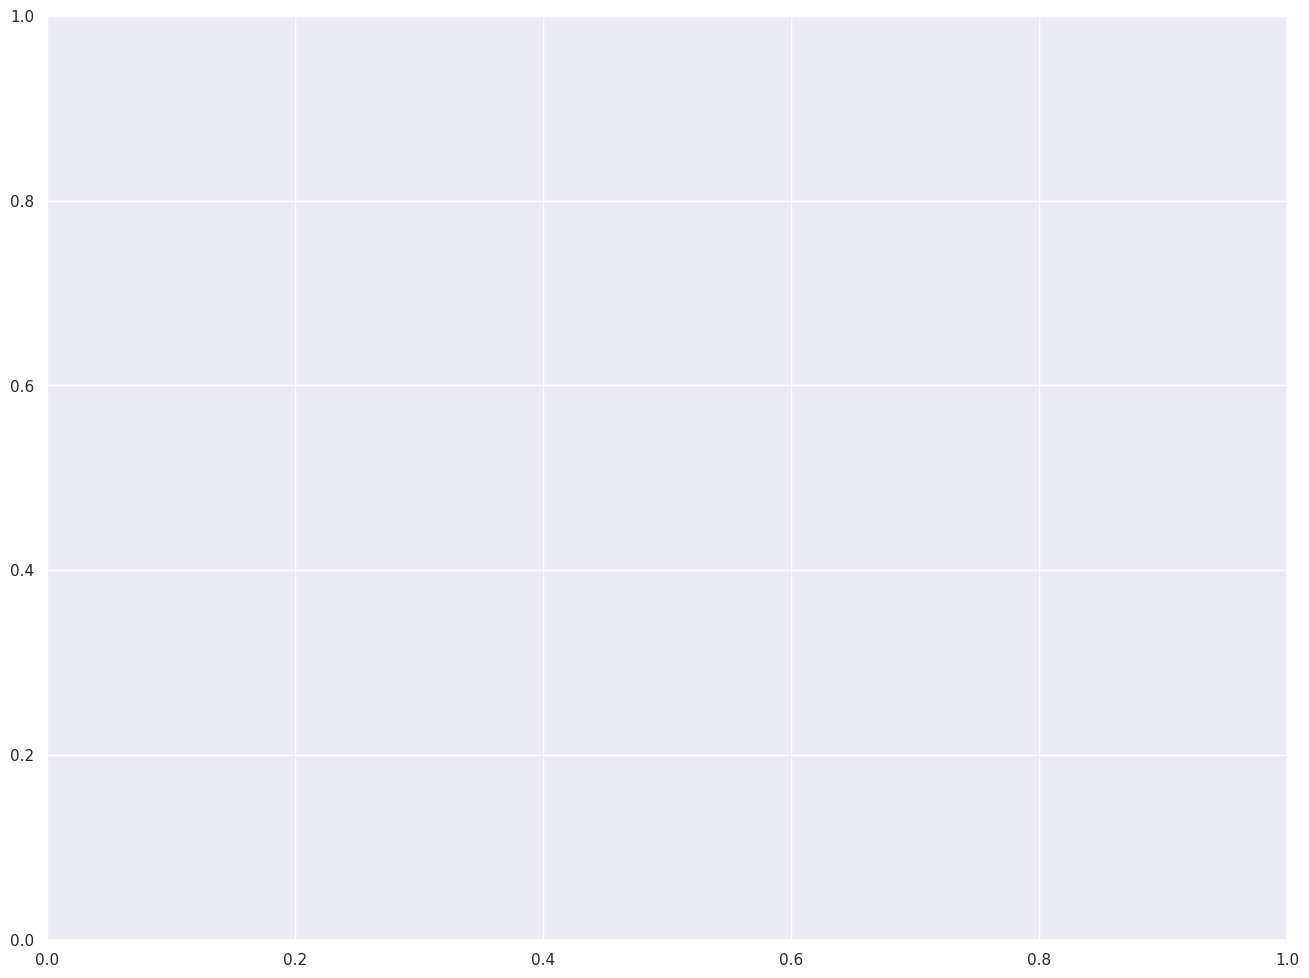

In [ ]:
for p in participants:
  print([s[1] for s in p.soas.items()])
  plt.plot([s[1] for s in p.soas.items()])
  plt.show()

## Model vs. Null

The experiment tests the hypothesis that alpha frequency interacts with perception. To test this hypothesis, a 10 Hz entrainment stimulus was used to modulate the alpha frequency while participants attempted to make a judgement about the relative location of two visual stimuli. Over many trials, the phase alignment of the stimulus display were systematically varied vis-a-vis the entrainment, then the mean response at each measured phase alignment were computed to generate a time-series response graph.

The null hypothesis, here, is that the alignment of the stimulus presentation to the entrainment signal has no effect on the judgement. To estimate this, the computed response values were randomly shuffled in the time domain.

The histogram below is of the power of the 10 Hz component of the frequency spectrum computed from the actual time-series and the shuffled, null, time-series.

Because of the sample sizes, the distribution can be seen to be non-normal.

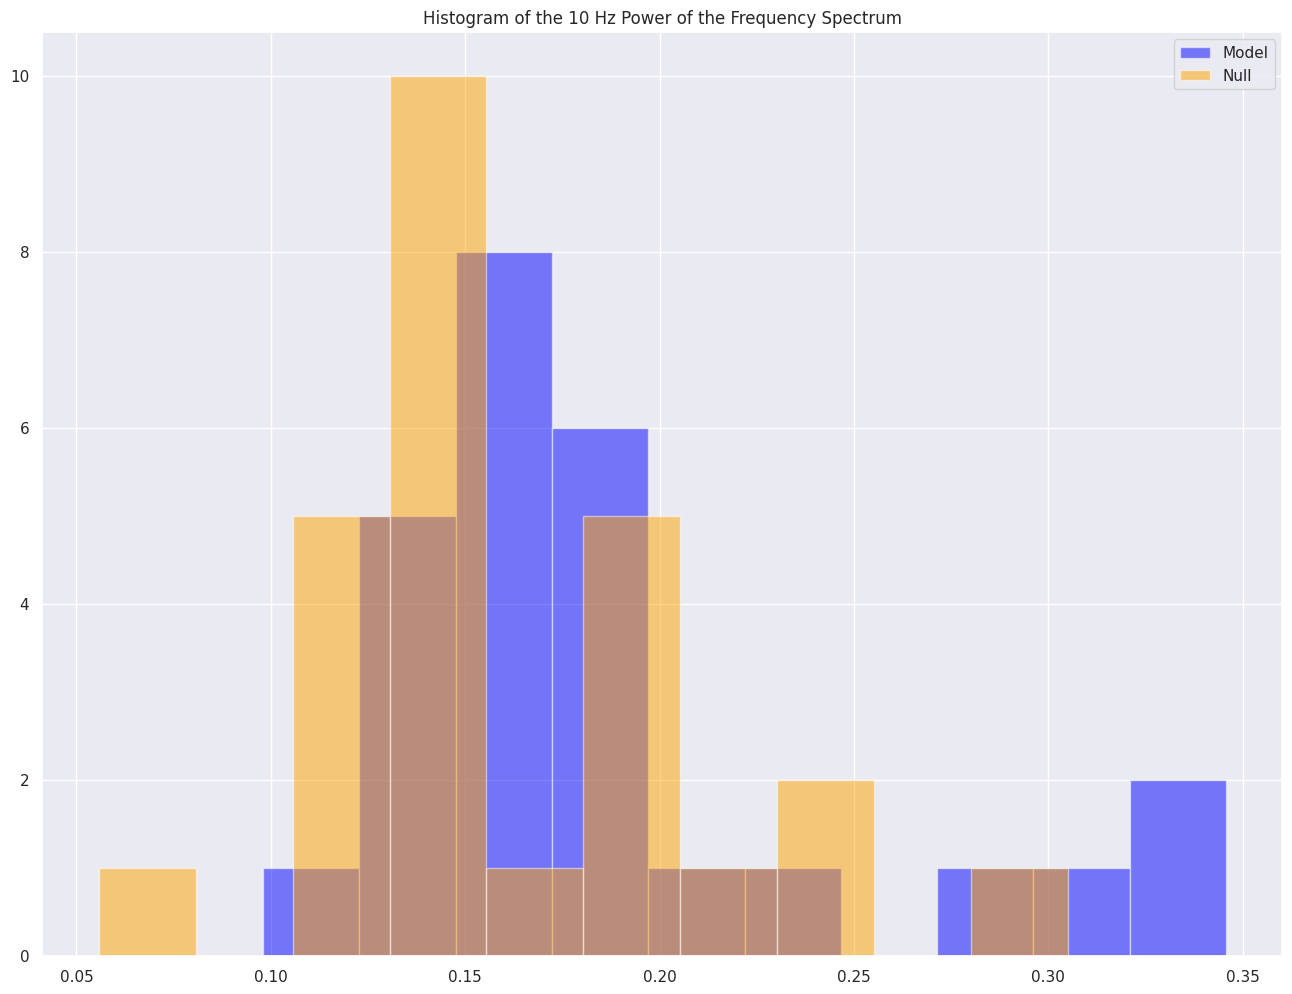

In [ ]:
plt.title("Histogram of the 10 Hz Power of the Frequency Spectrum")
plt.hist(np.array(model_means)[:, 5], color="blue", label="Model", alpha=0.5)
plt.hist(np.array(null_means)[:,5], color="orange", label="Null", alpha=0.5)
plt.legend()

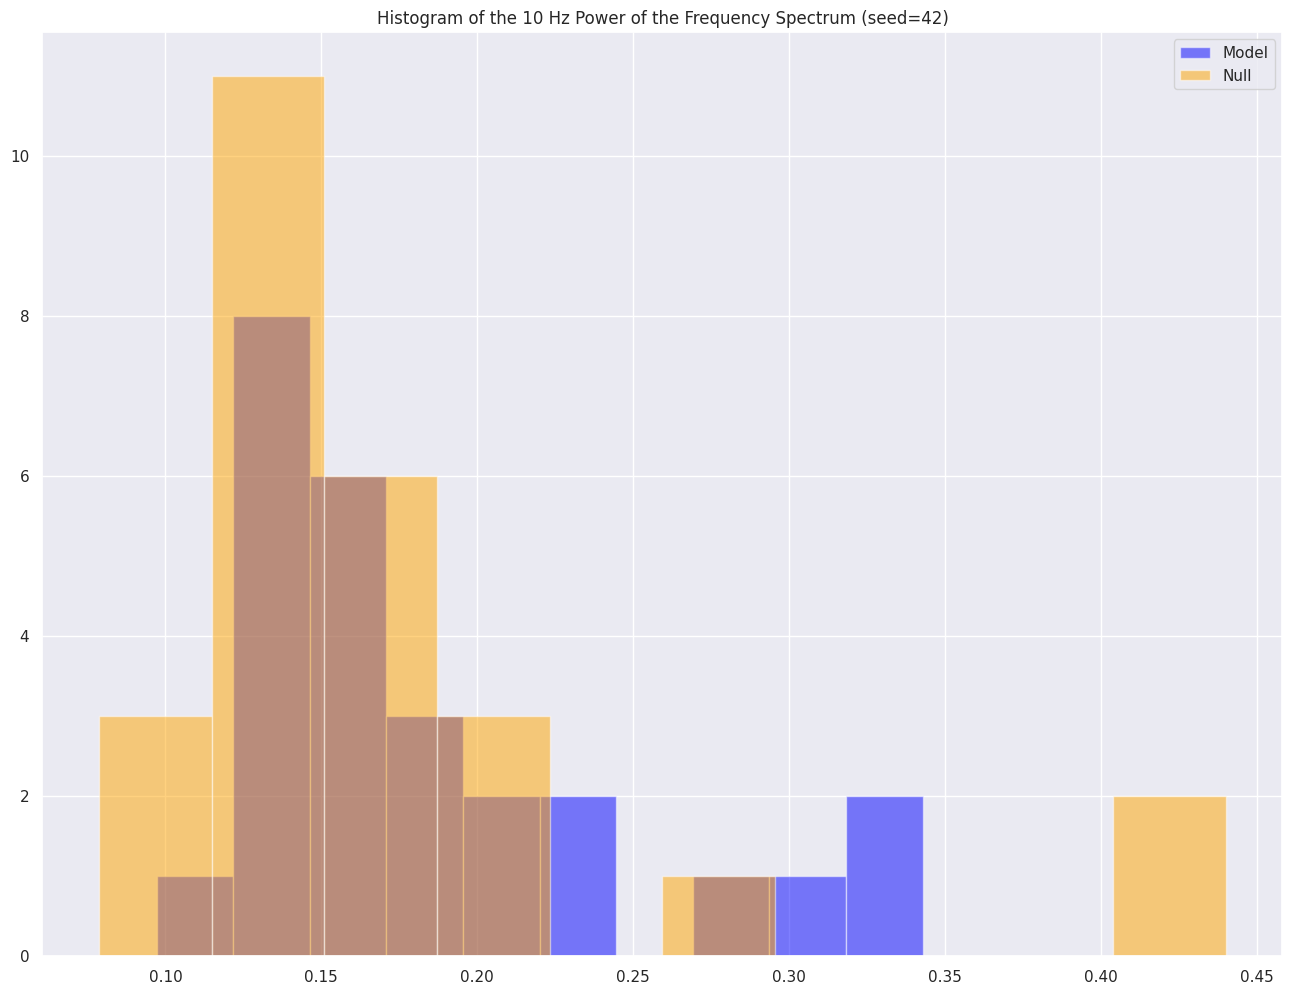

In [ ]:
plt.title("Histogram of the 10 Hz Power of the Frequency Spectrum (seed=42)")
plt.hist(np.array(model_means_42)[:, 5], color="blue", label="Model", alpha=0.5)
plt.hist(np.array(null_means_42)[:,5], color="orange", label="Null", alpha=0.5)
plt.legend()

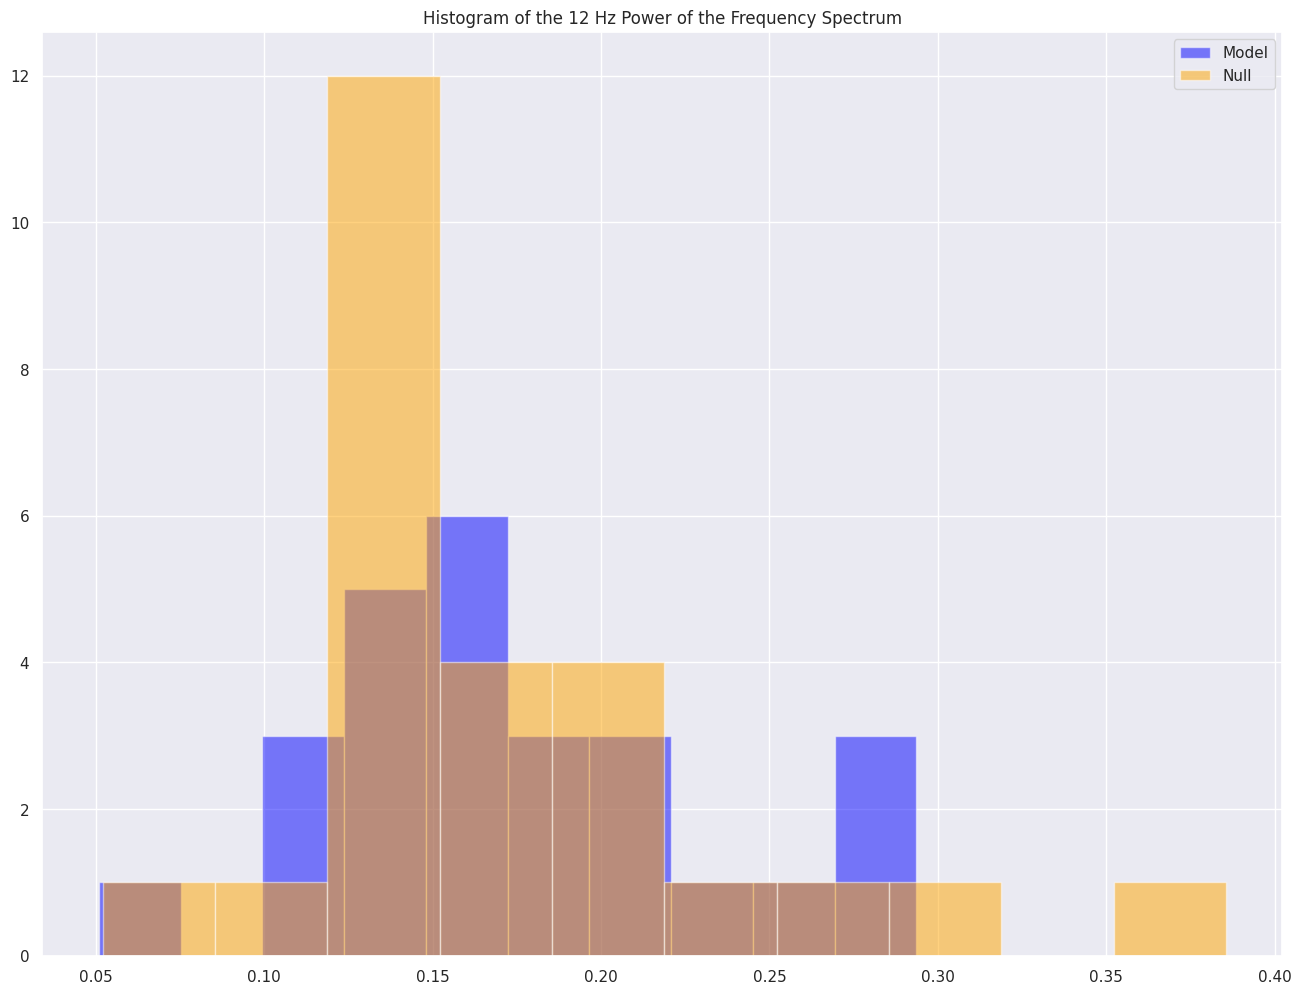

In [ ]:
plt.title("Histogram of the 12 Hz Power of the Frequency Spectrum")
plt.hist(np.array(model_means)[:, 6], color="blue", label="Model", alpha=0.5)
plt.hist(np.array(null_means)[:,6], color="orange", label="Null", alpha=0.5)
plt.legend()

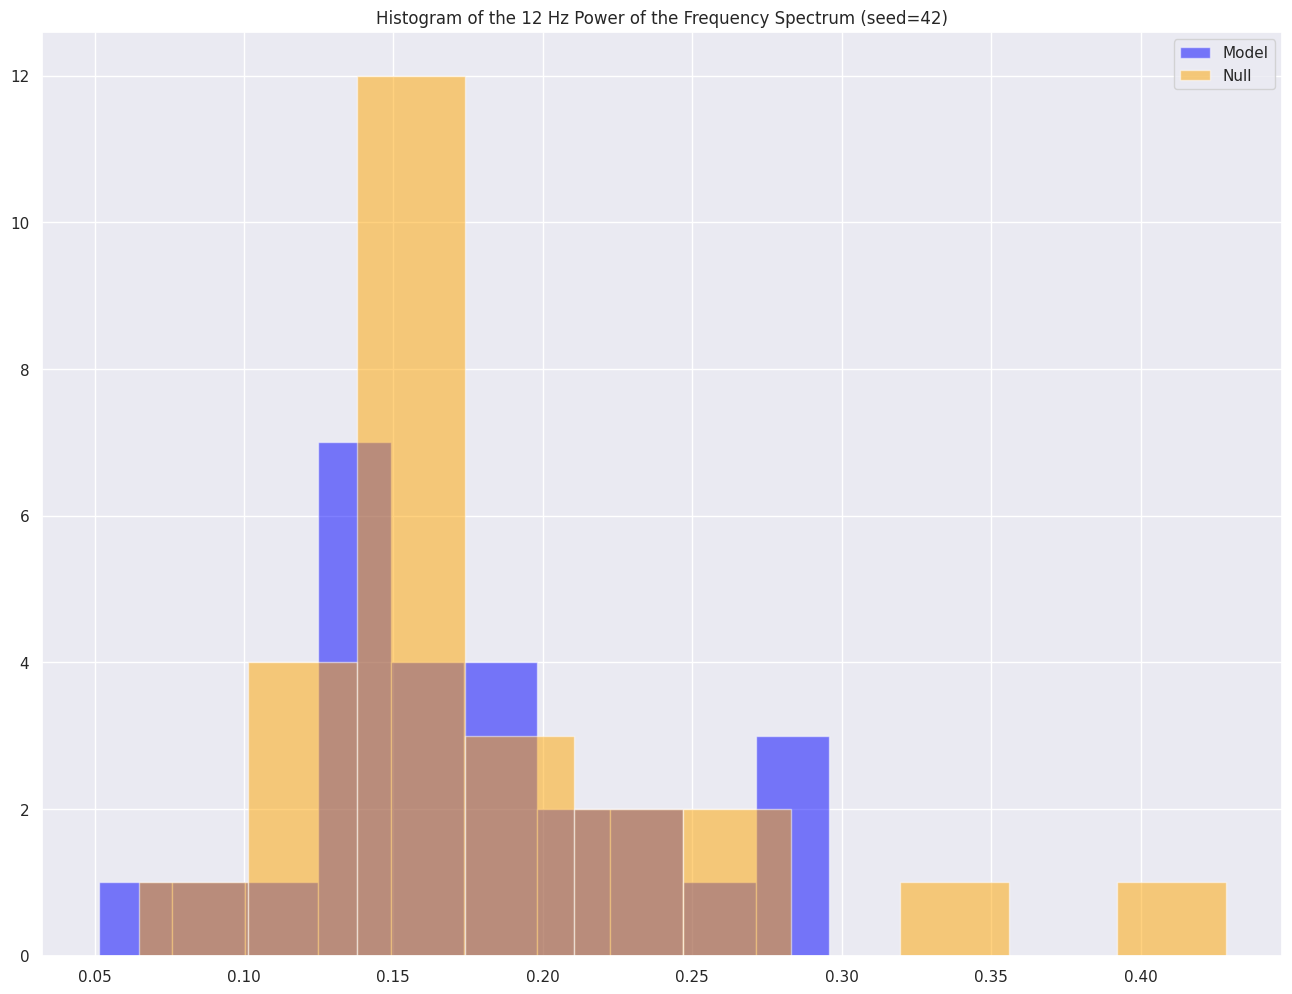

In [ ]:
plt.title("Histogram of the 12 Hz Power of the Frequency Spectrum (seed=42)")
plt.hist(np.array(model_means_42)[:, 6], color="blue", label="Model", alpha=0.5)
plt.hist(np.array(null_means_42)[:,6], color="orange", label="Null", alpha=0.5)
plt.legend()

## Bootstrapping

To deal with this non-normality, we can use bootstrapping to estimate normal distributions sampled from the same population.

In [ ]:
bootstrapped_mean_model_frequencies = sp.stats.bootstrap((model_means,),
                                                         np.mean,
                                                         confidence_level=0.95,
                                                         random_state=rng,
                                                         n_resamples=10000,
                                                         axis=0)
bootstrapped_mean_null_frequencies = sp.stats.bootstrap((null_means,),
                                                        np.mean,
                                                        confidence_level=0.95,
                                                        random_state=rng,
                                                        n_resamples=10000,
                                                        axis=0)

bootstrapped_std_model_frequencies = sp.stats.bootstrap((model_means,),
                                                         np.std,
                                                         confidence_level=0.95,
                                                         random_state=rng,
                                                         n_resamples=10000,
                                                         axis=0)
bootstrapped_std_null_frequencies = sp.stats.bootstrap((null_means,),
                                                        np.std,
                                                        confidence_level=0.95,
                                                        random_state=rng,
                                                        n_resamples=10000,
                                                        axis=0)





In [ ]:
bootstrapped_mean_model_frequencies_42 = sp.stats.bootstrap((model_means_42,),
                                                         np.mean,
                                                         confidence_level=0.95,
                                                         random_state=rng,
                                                         n_resamples=10000,
                                                         axis=0)
bootstrapped_mean_null_frequencies_42 = sp.stats.bootstrap((null_means_42,),
                                                        np.mean,
                                                        confidence_level=0.95,
                                                        random_state=rng,
                                                        n_resamples=10000,
                                                        axis=0)

bootstrapped_std_model_frequencies_42 = sp.stats.bootstrap((model_means_42,),
                                                         np.std,
                                                         confidence_level=0.95,
                                                         random_state=rng,
                                                         n_resamples=10000,
                                                         axis=0)
bootstrapped_std_null_frequencies_42 = sp.stats.bootstrap((null_means_42,),
                                                        np.std,
                                                        confidence_level=0.95,
                                                        random_state=rng,
                                                        n_resamples=10000,
                                                        axis=0)


## Bootstrapped Means

Here we plot the 95% confidence interval of the bootstrapped actual and null hypothesis distributions. Because we don't care about the full frequency spectrum and to avoid having the 0-1Hz power swamp the plot we filtered the data from 4 - 18 Hz. The 10 Hz component is marked with a vertical line and close examination demonstrates that the means of each of the two classes fall outside of the 95% confidence intervals of the othe class.

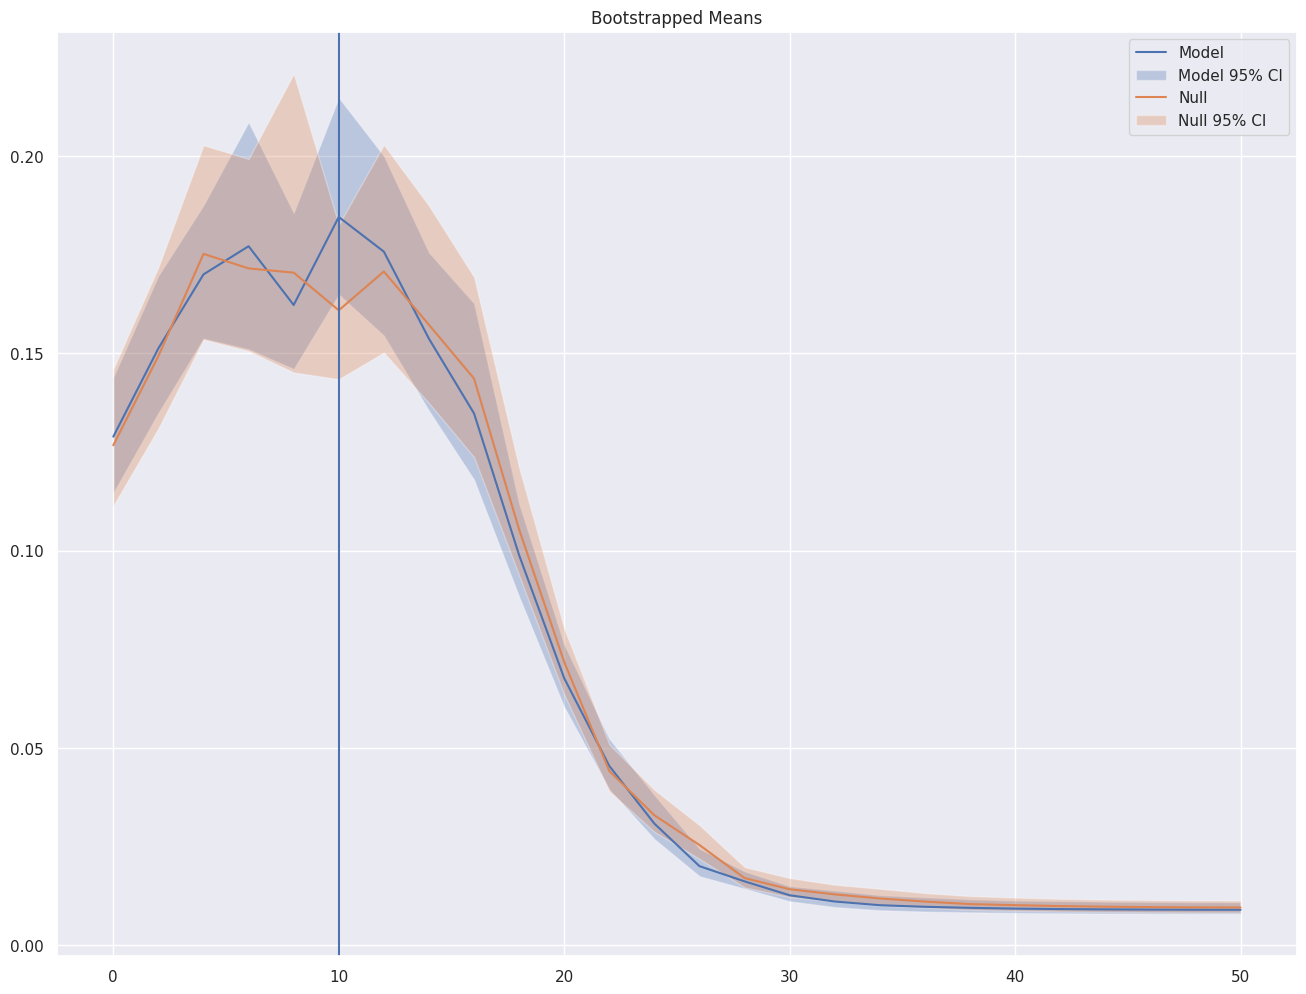

In [ ]:
plt.title("Bootstrapped Means")
plot_ci(bootstrapped_mean_model_frequencies, label="Model")
plot_ci(bootstrapped_mean_null_frequencies, label="Null")
plt.axvline(10)
plt.legend()
plt.show()

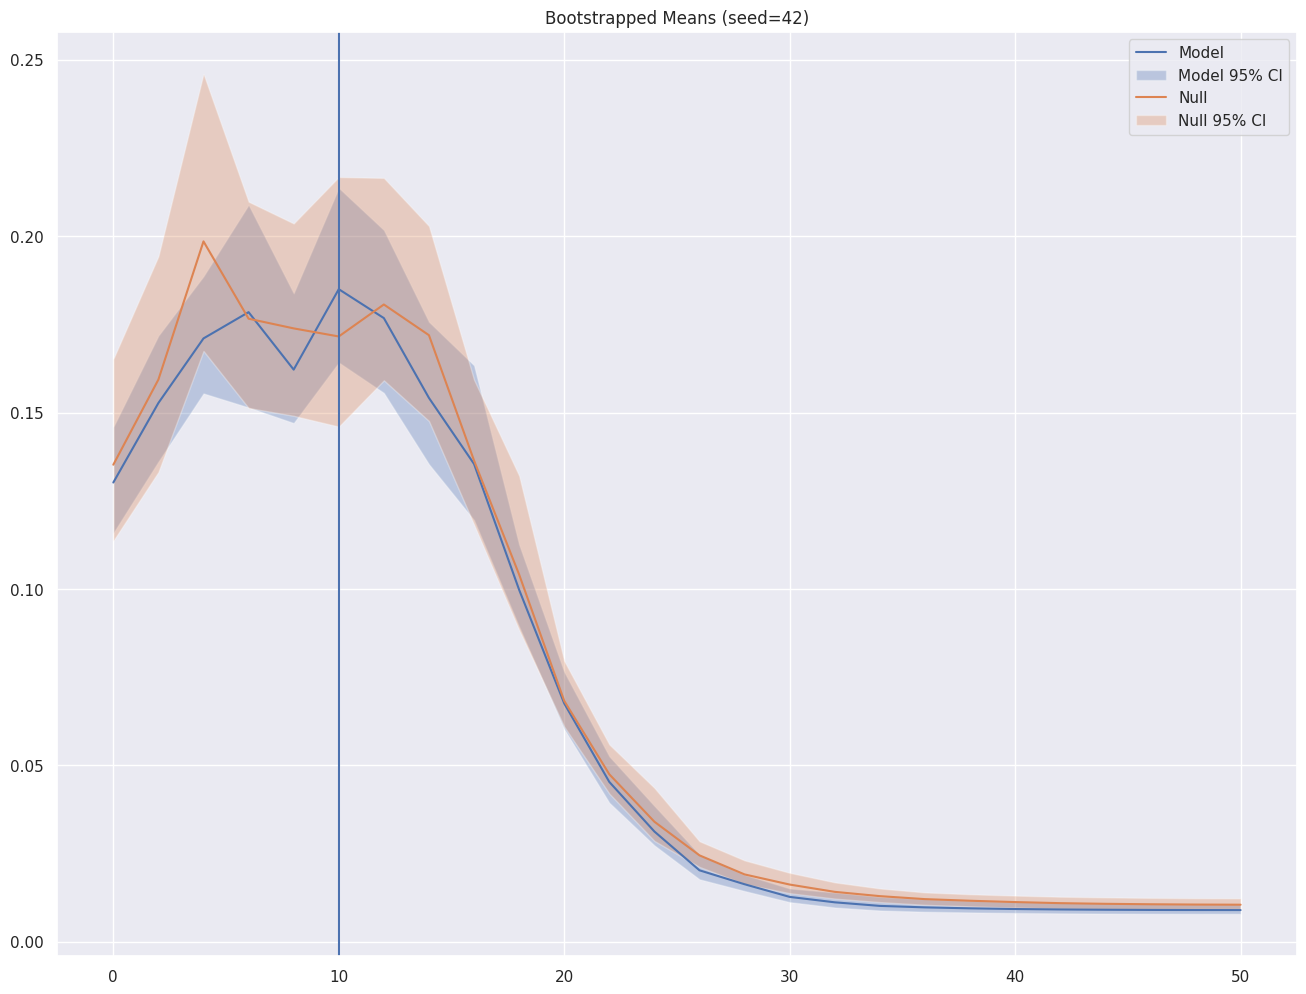

In [ ]:
plt.title("Bootstrapped Means (seed=42)")
plot_ci(bootstrapped_mean_model_frequencies_42, label="Model")
plot_ci(bootstrapped_mean_null_frequencies_42, label="Null")
plt.axvline(10)
plt.legend()
plt.show()

## Bootstrapped Standard Deviations

We computed these values, but I am not sure what their interpretation suggests. I leave this here in case we decide there is some value in this plot.

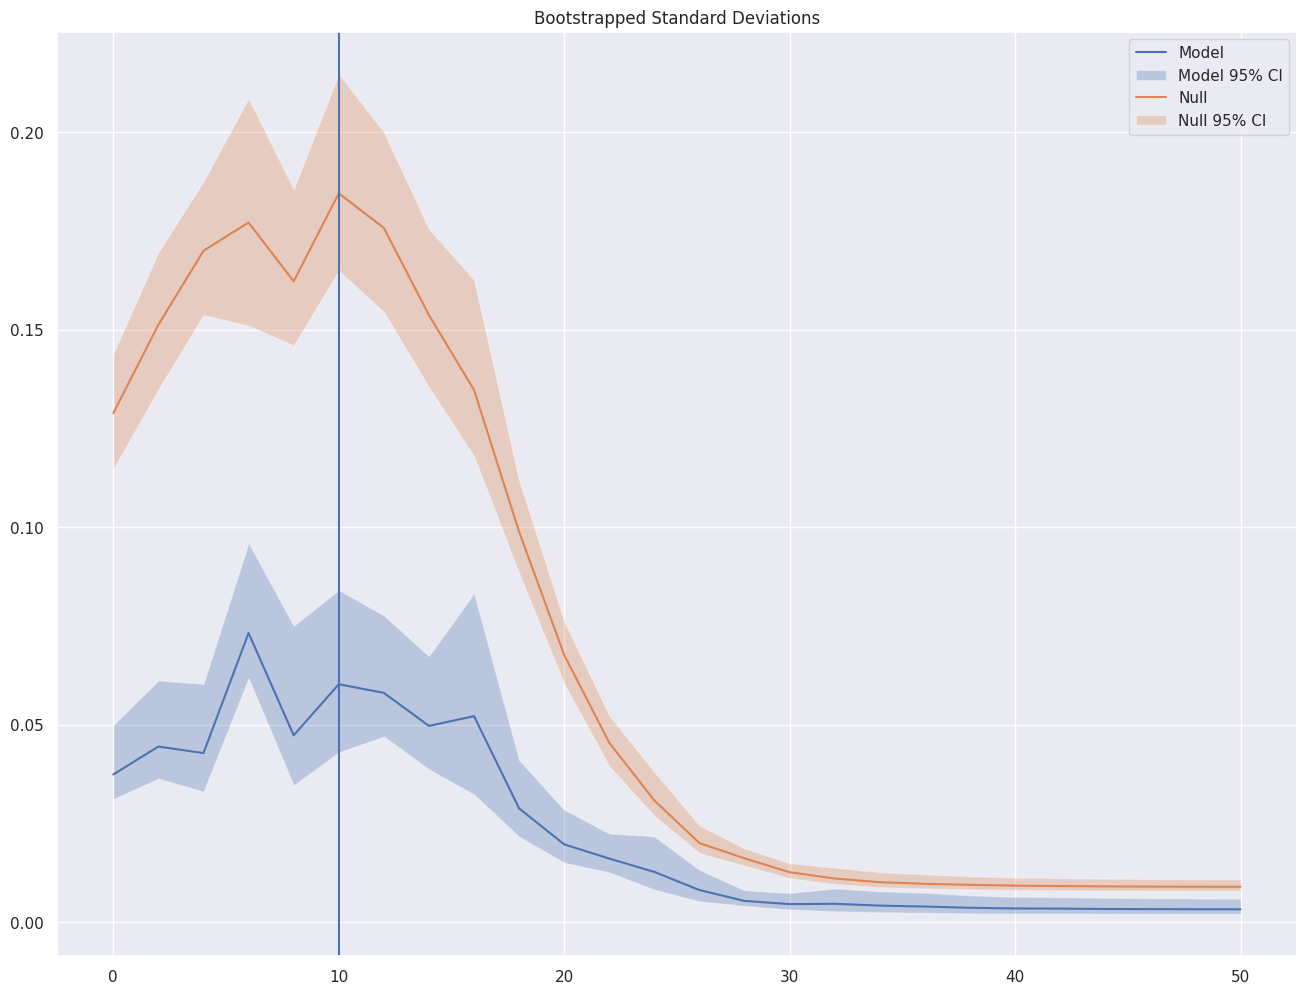

In [ ]:
plt.title("Bootstrapped Standard Deviations")
plot_ci(bootstrapped_std_model_frequencies, label="Model")
plot_ci(bootstrapped_mean_model_frequencies, label="Null")
plt.axvline(10)
plt.legend()
plt.show()

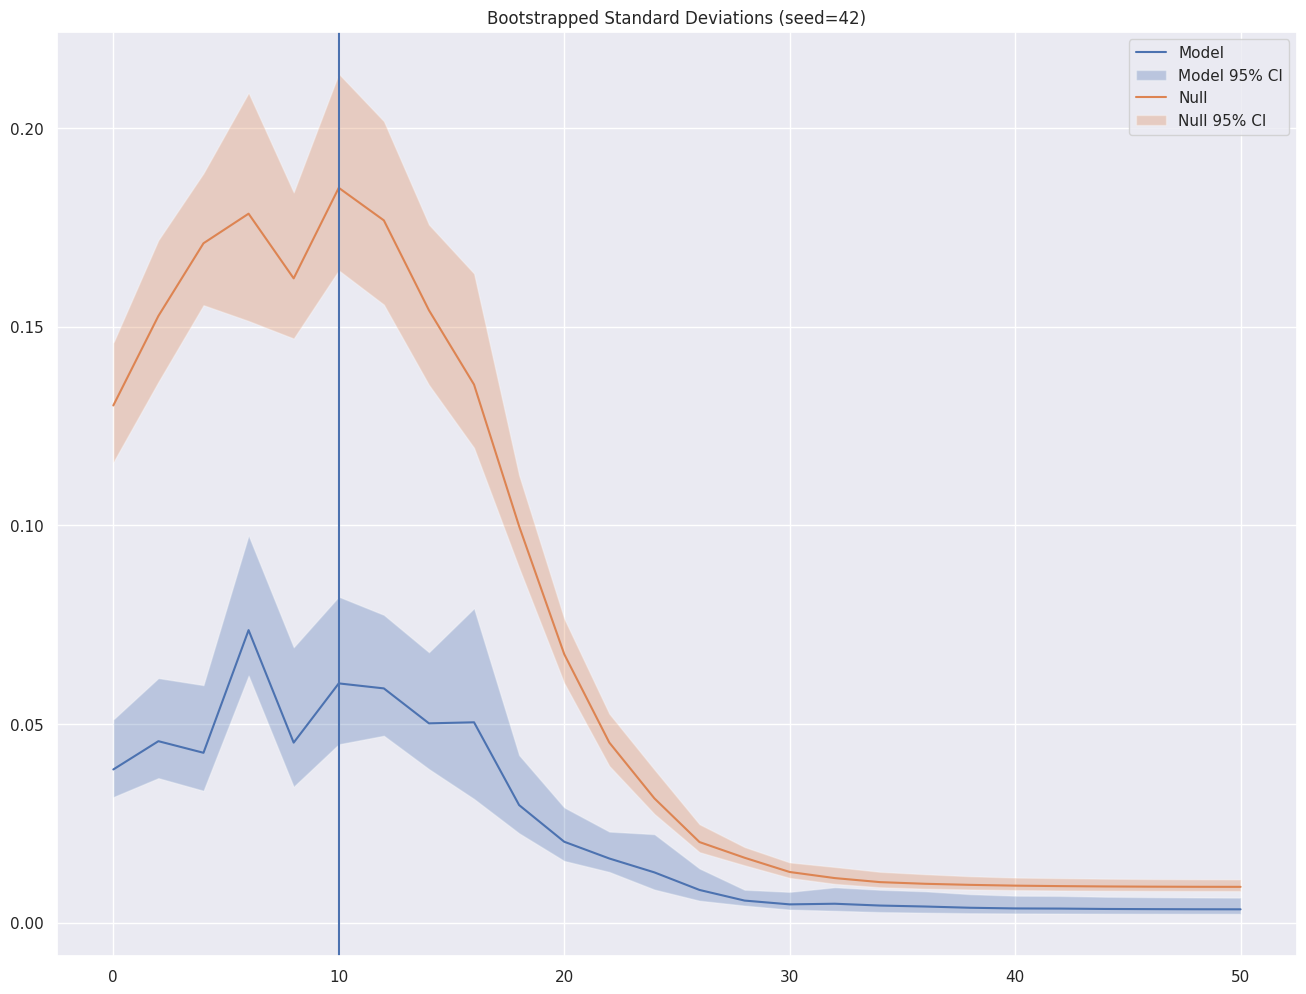

In [ ]:
plt.title("Bootstrapped Standard Deviations (seed=42)")
plot_ci(bootstrapped_std_model_frequencies_42, label="Model")
plot_ci(bootstrapped_mean_model_frequencies_42, label="Null")
plt.axvline(10)
plt.legend()
plt.show()

## Bootstrapped 10 Hz Component of the Frequency Power Spectrum

This is the equivalent of the previous histogram showing that the null and actual data are now both normally distributed. Additionally, the look to be different, which is what we hoped to show.

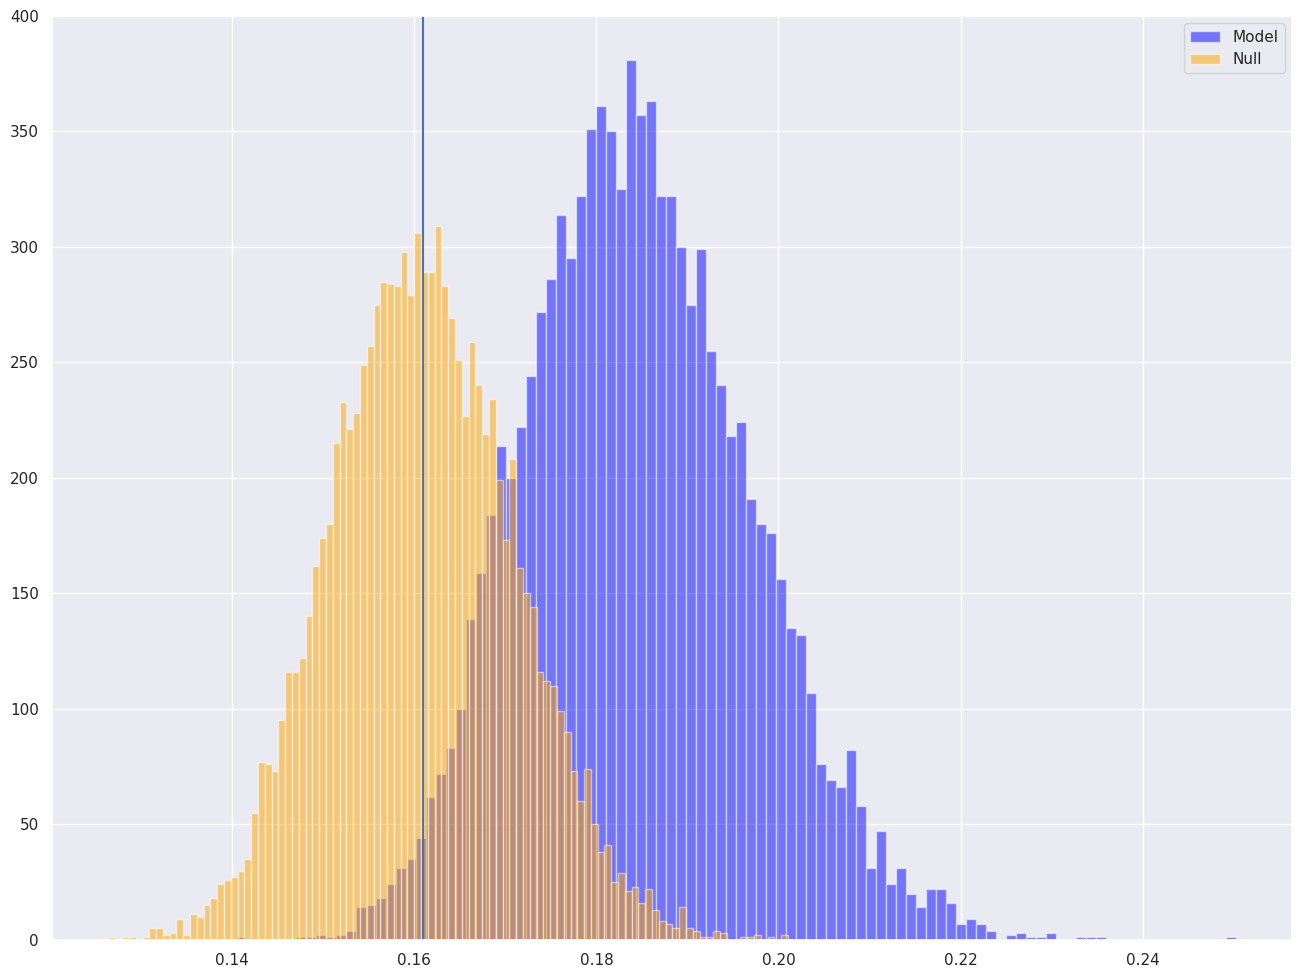

In [ ]:
plt.hist(bootstrapped_mean_model_frequencies.bootstrap_distribution[5,:], color="blue", label="Model", alpha = 0.5, bins=100)
plt.hist(bootstrapped_mean_null_frequencies.bootstrap_distribution[5,:], color="orange", label="Null", alpha = 0.5, bins=100)
plt.axvline(np.mean(bootstrapped_mean_null_frequencies.bootstrap_distribution[5,:]))
plt.legend()

## Significance

To determine significance we calculate a likelihood whereby we measure what percentage of the distribution of the histogram of the actual signal falls at or below the mean of the null (shuffled) histogram.

In [ ]:
model_null_count = 0
for f in bootstrapped_mean_model_frequencies.bootstrap_distribution[5, :]:
    if f <= np.mean(bootstrapped_mean_null_frequencies.bootstrap_distribution[5, :]):
        model_null_count += 1

print(model_null_count / bootstrapped_mean_model_frequencies.bootstrap_distribution[5, :].size)

0.0177


## Systematic Issue?

Here we perform a small sanity check. Instead of looking at the 10 Hz component we look at the 6 Hz component. We would expect the actual signal here not to differ significantly from the null histogram. If this expectation is violatated it would suggest there may be a systematic error in our analysis that may give rise to the significance detailed above.

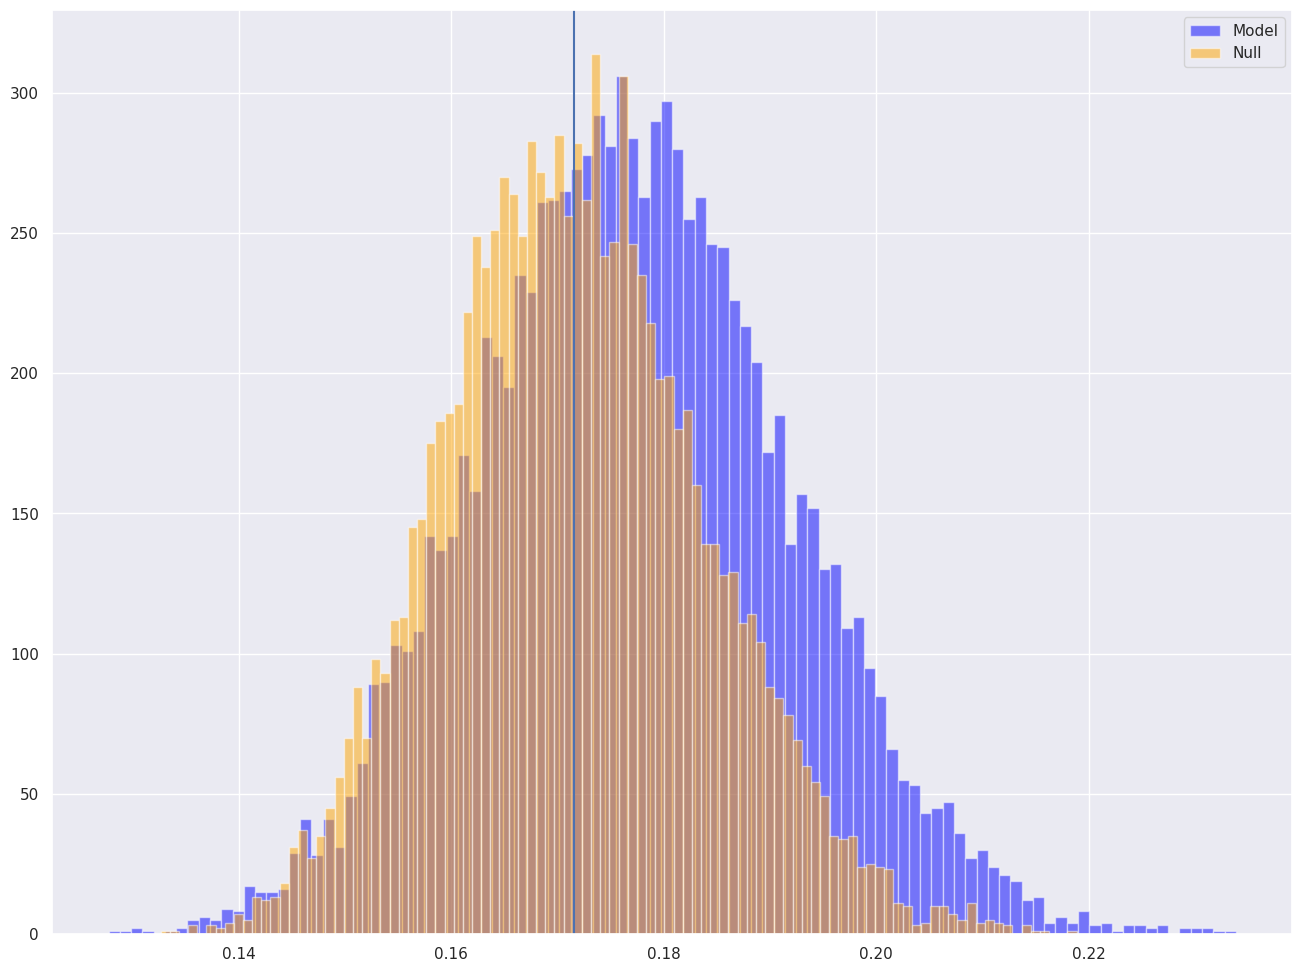

In [ ]:
plt.hist(bootstrapped_mean_model_frequencies.bootstrap_distribution[3,:], color="blue", label="Model", alpha = 0.5, bins=100)
plt.hist(bootstrapped_mean_null_frequencies.bootstrap_distribution[3,:], color="orange", label="Null", alpha = 0.5, bins=100)
plt.axvline(np.mean(bootstrapped_mean_null_frequencies.bootstrap_distribution[3,:]))
plt.legend()

## Significant Overlap

Informally, we can see that there is significant overlap between these two histograms. What is the significance of the difference between these two histograms using our previous measure?

In [ ]:
model_null_count_6hz = 0
for f in bootstrapped_mean_model_frequencies.bootstrap_distribution[3, :]:
    if f <= np.mean(bootstrapped_mean_null_frequencies.bootstrap_distribution[3, :]):
        model_null_count_6hz += 1

print(model_null_count_6hz / bootstrapped_mean_model_frequencies.bootstrap_distribution[3, :].size)

0.3561


## Result

We find a significant difference, by our measure, where we expect it (at 10 Hz) and no significant difference where we expect none (at 6 Hz).